Base Model 1 : 단일 변수 이상 탐지

In [1]:
import pandas as pd
import numpy as np

In [6]:
df_test = pd.read_csv('test_features.csv')
df_train = pd.read_csv('train_features.csv')
df_valid = pd.read_csv('valid_features.csv')

In [7]:
#3개의 df 각각 전처리

feature_cols = [
    "vol_chg_rate",
    "volume_ma20_ratio",
    "daily_return",
    "volatility_5d",
    "drawdown_after_peak_5d",
    "upper_shadow_ratio",
    "body_ratio",
    "upper_shadow_streak_5d"
]
df_train["volume_ma20_ratio"] = df_train["volume_ma20_ratio"].replace([np.inf, -np.inf], np.nan)
df_train = df_train.dropna(subset=["volume_ma20_ratio"]).copy()

df= pd.concat([df_test,df_valid], ignore_index=True)

df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=feature_cols).copy()
for col in feature_cols:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(lower, upper)

X=df['volume_ma20_ratio'].copy()

In [9]:
#Isolation Forest로 이상치 탐지
from sklearn.ensemble import IsolationForest

iso_model = IsolationForest(
    n_estimators=200,
    contamination=0.03,
    random_state=42
)
iso_model.fit(df_train[['volume_ma20_ratio']])

#이상치 점수
df["anomaly_score"] = -iso_model.decision_function(df[['volume_ma20_ratio']])
#label명 바꾸기 (정상:1, 이상치:-1) => (정상:0, 이상치:1)
df["anomaly_label"] = iso_model.predict(df[['volume_ma20_ratio']])
df["anomaly_label"] = df["anomaly_label"].map({1: 0, -1: 1})

#정상 데이터와 이상 데이터 개수 표시
df["anomaly_label"].value_counts()

anomaly_label
0    7203
1     211
Name: count, dtype: int64

결과 시각화

모델 성능 시각화: tsne 활용 차원 감소 후 산점도를 통한 시각

In [10]:
from sklearn.manifold import TSNE

X_tsne = df[feature_cols].copy()
tsne = TSNE(n_components=2, random_state=42)
tsne_results = tsne.fit_transform(df[feature_cols])

C:\asdf\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] 지정된 파일을 찾을 수 없습니다
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\asdf\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "C:\asdf\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\asdf\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\asdf\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(a

In [11]:
df_tsne = pd.DataFrame(tsne_results, columns=['tsne_1', 'tsne_2'])
df_tsne['anomaly_label'] = df['anomaly_label']

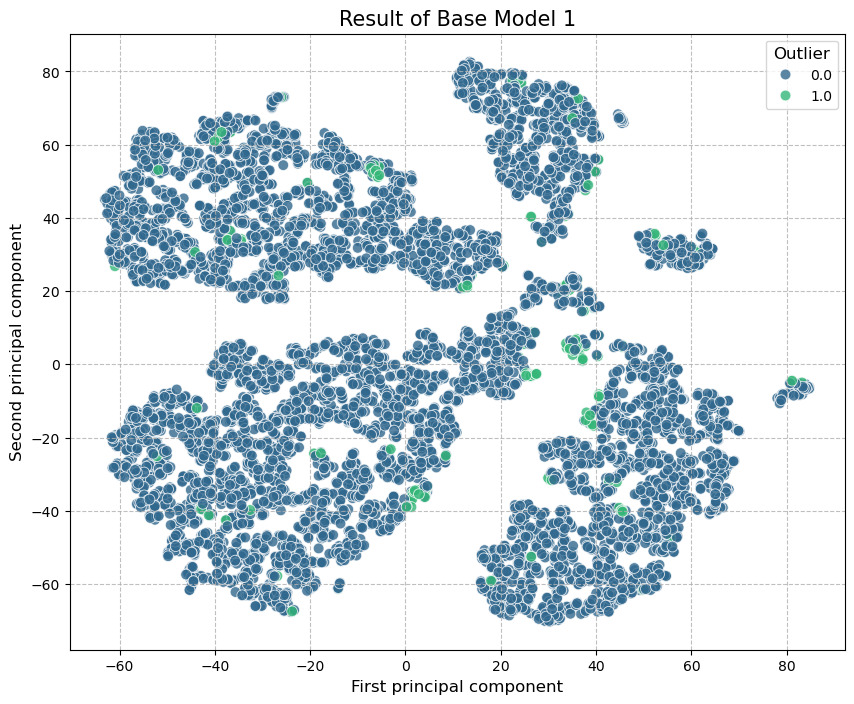

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))
sns.scatterplot(data=df_tsne, x='tsne_1', y='tsne_2', hue='anomaly_label', 
                palette='viridis', s=60, alpha=0.8, edgecolor='w', legend='full')

plt.title('Result of Base Model 1', fontsize=15)
plt.xlabel('First principal component', fontsize=12)
plt.ylabel('Second principal component', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.8)
plt.legend(title='Outlier', title_fontsize=12, fontsize=10)
plt.savefig('base_model1_result.png', dpi=300, bbox_inches="tight")
plt.show()